**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

**Load the Dataset**

In [2]:
df = pd.read_csv("wine.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Understand the Dataset**

In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


**Check Missing Values**

In [5]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


**Check Duplicate Rows**

In [6]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

**Exploratory Data Analysis (EDA)**

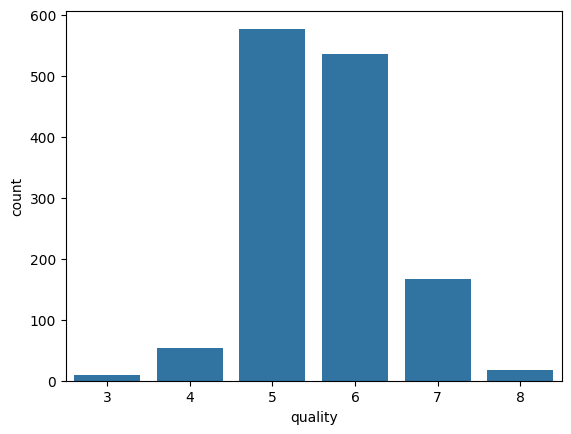

In [8]:
#Distribution of Quality
sns.countplot(x="quality", data=df)
plt.show()

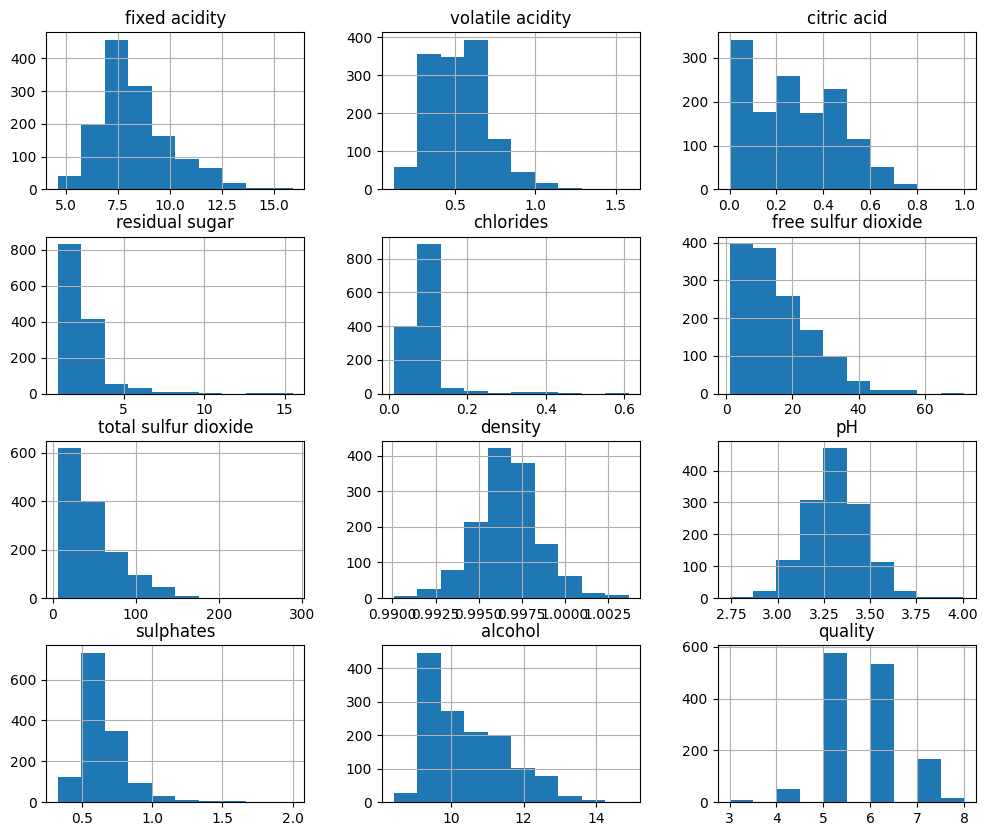

In [9]:
#Histogram
df.hist(figsize=(12,10))
plt.show()

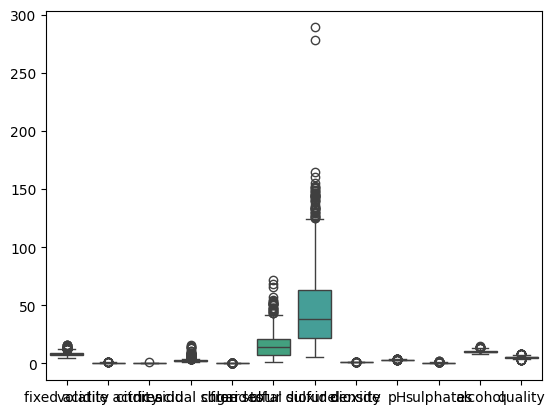

In [10]:
#Boxplot
sns.boxplot(data=df)
plt.show()

**Correlation Analysis**

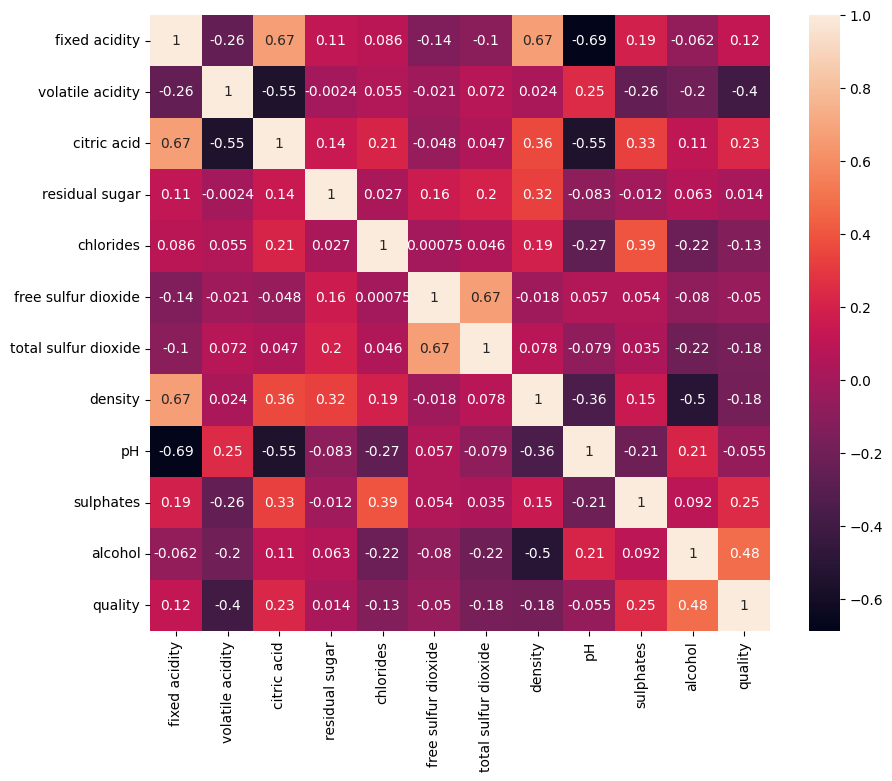

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

**Separate Features and Target**

In [12]:
X = df.drop("quality", axis=1)
y = df["quality"]

**Split Data**

80% training
20% testing

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Regression Model**

In [15]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mean_absolute_error(y_test, y_pred)

0.4708823529411764

**RMSE**

In [16]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(0.6137732863678766)

**R² Score**

In [17]:
r2_score(y_test, y_pred)

0.4681802354647281

**Feature Importance**

<Axes: >

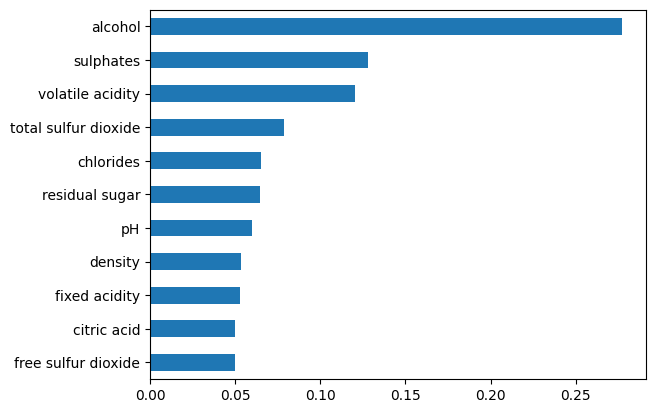

In [18]:
importance = model.feature_importances_

pd.Series(
    importance,
    index=X.columns
).sort_values().plot(kind="barh")

**Classification Problem**

In [21]:
df["quality_label"] = df["quality"].apply(
    lambda x: 1 if x >= 7 else 0
)

In [22]:
X = df.drop(["quality","quality_label"], axis=1)

y = df["quality_label"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Train Classification Model**

In [25]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
55,7.7,0.620,0.04,3.8,0.084,25.0,45.0,0.99780,3.34,0.53,9.5
1291,8.2,0.635,0.10,2.1,0.073,25.0,60.0,0.99638,3.29,0.75,10.9
1544,8.4,0.370,0.43,2.3,0.063,12.0,19.0,0.99550,3.17,0.81,11.2
593,9.9,0.490,0.58,3.5,0.094,9.0,43.0,1.00040,3.29,0.58,9.0
1261,6.3,1.020,0.00,2.0,0.083,17.0,24.0,0.99437,3.59,0.55,11.2
...,...,...,...,...,...,...,...,...,...,...,...
1086,8.5,0.340,0.40,4.7,0.055,3.0,9.0,0.99738,3.38,0.66,11.6
662,7.2,0.570,0.06,1.6,0.076,9.0,27.0,0.99720,3.36,0.70,9.6
279,8.9,0.400,0.32,5.6,0.087,10.0,47.0,0.99910,3.38,0.77,10.5
1111,5.4,0.420,0.27,2.0,0.092,23.0,55.0,0.99471,3.78,0.64,12.3


**Evaluate Classification**

In [27]:
#Accuracy
accuracy_score(y_test, y_pred)

0.8676470588235294

In [28]:
#Precision
precision_score(y_test, y_pred)

0.47368421052631576

In [29]:
#Recall
recall_score(y_test, y_pred)

0.5294117647058824

In [30]:
#F1
f1_score(y_test, y_pred)

0.5

In [31]:
#Confusion Matrix
confusion_matrix(y_test, y_pred)

array([[218,  20],
       [ 16,  18]])

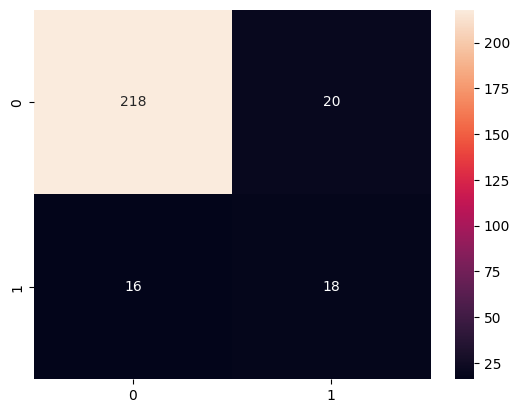

In [32]:
#Visualize
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt="d")
plt.show()

**Business Insights**

1. Alcohol has a positive effect on wine quality.
2. High volatile acidity decreases quality.
3. Sulphates improve quality.
4. The model can help wineries predict quality before selling products.
5. Poor-quality batches can be identified early.
6. Premium wines can be separated automatically.

**Conclusion**

This project used machine learning to predict red wine quality using physicochemical properties. A regression model estimated the exact quality score, while a classification model categorized wines as good or bad. Data preprocessing, visualization, and model evaluation demonstrated how machine learning can support quality control and decision-making in the wine industry.